In [2]:
using Pkg
Pkg.activate("../scripts/calval")
using IceFloeTracker
using Images
using DataFrames
using CSVFiles
using CairoMakie
using GLM
using StatsBase

  Activating project at `~/Documents/research/manuscripts/calval_tgrs/scripts/calval`


# Filter Floes
The filter floes function is designed to remove false positives prior to the "merge floes" step. To calibrate the filter floes function, we identify objects from each processing pipeline belonging to no relevant sets based on the manually identified floes.

We first load the data.

In [54]:
dataset = Watkins2026Dataset(;
    url="https://github.com/danielmwatkins/ice-floe-validation-dataset/",
    ref="v0.2",
    cache_dir="/tmp/Watkins2026",
    metadata_path="data/validation_dataset/validation_dataset.csv",
)

#### Run this to use the previously defined test/train split ####
prior_data = DataFrame(load("../data/train_test_split.csv"))
dataset.info[:, :training_sample] = parse.(Bool, prior_data[:, :training_sample])
dataset.info[:, :testing_sample] = parse.(Bool, prior_data[:, :testing_sample])
train_cases = filter(c -> c.training_sample, dataset) 
test_cases = filter(c -> c.testing_sample, dataset);

train_cases.info[:, :lookup_index] = 1:nrow(train_cases.info)
test_cases.info[:, :lookup_index] = 1:nrow(test_cases.info);

cluster_algo = IceDetectionBrightnessPeaksMODIS721(;
        band_7_max=0.16,
        possible_ice_threshold=0.6,
        join_method="union",
        minimum_prominence=0.01,
    )

cleanup_binary_params = (erosion_strel=strel_box((3, 3)), init_max_fill=100, conditional_max_fill=500
)
floe_splitting_params = (max_hole_fill=2000, max_distance=5, max_expand=3)

function clean_split_label(binary_mask, ice_mask, cloud_mask)
    return FSPipeline.dist_morph_split(
        FSPipeline.clean_binary_floes(binary_mask, ice_mask, cloud_mask; cleanup_binary_params...);
        floe_splitting_params...,
    )
end

# Workflows produce labeled arrays, not segmented images
function kmeans_workflow(preproc_gray, fc_masked, land_mask, ice_mask, cloud_mask; k=4, cluster_selection_algorithm=cluster_algo)
    masked_gray = apply_landmask(preproc_gray, land_mask)
    kmeans_result = kmeans_binarization(
        masked_gray, fc_masked; k=k, cluster_selection_algorithm=cluster_algo) .> 0
    return clean_split_label(kmeans_result, ice_mask, cloud_mask)
end

function adaptive_workflow(preproc_gray, land_mask, ice_mask, cloud_mask; window_size=400, percentage=0)
    water_mask = .!(ice_mask .|| cloud_mask .|| land_mask) 
    adaptive_result = binarize(preproc_gray, AdaptiveThreshold(; window_size=window_size, percentage=percentage)) .> 0
    apply_landmask!(adaptive_result, land_mask)
    apply_landmask!(adaptive_result, water_mask)
    return clean_split_label(adaptive_result .> 0, ice_mask, cloud_mask)    
end

adaptive_workflow (generic function with 2 methods)

In [4]:
case = train_cases

function fill_missing!(cases; template=Gray.(zeros(Bool, (400, 400))))
    for (idx, img) in enumerate(cases)
        if isnothing(img)
            cases[idx] = template
        end
    end
end

cloud_mask_function = Watkins2026CloudMask(
    band_7_threshold=0.16,
    band_2_threshold=0.34,
    opening_strel=strel_disk(3),
    dilation_strel=strel_disk(2)
)

ice_mask_function = IceDetectionBrightnessMidpoint(; minimum_reflectance=0.45)

@time begin
    tc_imgs = modis_truecolor.(case)
    fc_imgs = modis_falsecolor.(case)
    land_masks = modis_landmask.(case) .|> r -> r .> 0
    cloud_masks = cloud_mask_function.(fc_imgs)
    coastal_buffers = create_coastal_buffer_mask.(land_masks, [strel_box((25,25))])
    
    # joint_mask_buffers = ((x, y) -> x .|| y).(coastal_buffers, cloud_masks)
    
    # Mask images before k-means, preliminary ice mask application
    tc_masked = apply_landmask.(tc_imgs, land_masks)
    fc_masked = apply_landmask.(fc_imgs, land_masks)
    fc_buffered = apply_landmask.(fc_imgs, coastal_buffers)
    band_1 = fc_masked .|> r -> Gray.(blue.(r))
    ice_masks = ice_mask_function.(band_1) .|> r -> r .> 0
    # Masks have to be a full partition for this to work. So if the coastal buffer is used to make
    # the ice mask, it also must be used for the land mask here.
    water_masks = ((x, y, z) -> .!x .&& .!y .&& .!z).(land_masks, cloud_masks, ice_masks)
    
    # reference images
    binary_floes = validated_binary_floes.(case)
    fill_missing!(binary_floes)
end
nothing

191.974440 seconds (46.96 M allocations: 4.275 GiB, 1.21% gc time, 1 lock conflict, 4.24% compilation time: 5% of which was recompilation)


In [5]:
preproc_function = FSPipeline.Preprocess(
    diffusion_algorithm = PeronaMalikDiffusion(; λ=0.1, K=0.1, niters=5, g="exponential"),
    adapthisteq_params = (nbins=256, rblocks=2, cblocks=2, clip=5),
    unsharp_mask_params = (radius=50, amount=0.3, threshold=0.01),
)
tiles = get_tiles(tc_imgs[1], (400, 400)) # single tile
preproc_gray = preproc_function.(tc_imgs, land_masks, [tiles]);

In [55]:
adapt_labels = adaptive_workflow.(preproc_gray, land_masks, ice_masks, cloud_masks; window_size=200, percentage=0);
kmeans_labels = kmeans_workflow.(preproc_gray, fc_buffered, land_masks, ice_masks, cloud_masks);

# Get floe properties for training

In [335]:
colnames = [
    :area, :col_centroid, :convex_area, :label, :major_axis_length,
    :max_col, :max_row, :min_col, :min_row, :minor_axis_length, 
    :orientation, :perimeter, :row_centroid, :circularity,
    :cloud_fraction, :b2_reflectance_mean, :b2_reflectance_bdry_mean]

function extended_regionprops(
        img_indexmap, coastal_buffer_mask, cloud_mask, fc_img;
        min_floe_size=100, max_floe_size=90e3, expand_radius=15, colnames=colnames)

    overlap = unique(img_indexmap[coastal_buffer_mask])
    indices = component_indices(img_indexmap)
    
    for L in overlap
        img_indexmap[indices[L]] .= 0
    end

    # Remove floes outside the specified bounds
    remove_small_segments!(img_indexmap, min_floe_size)
    remove_large_segments!(img_indexmap, max_floe_size)
    maximum(img_indexmap) == 0 && return DataFrame(Dict(r => [] for r in colnames))
    
    results_df = regionprops_table(img_indexmap;
        properties=[:label, :area, :convex_area, :perimeter, :bbox, :centroid,
                    :major_axis_length, :minor_axis_length, :orientation]
    )
    
    results_df[:, :circularity] = 4 * π * results_df[:, :area] ./ results_df[:, :perimeter] .^ 2
    
    labels = results_df[:, :label]
    cloud_fractions = Dict(L => mean(cloud_mask[indices[L]]) for L in labels)
    results_df[:, :cloud_fraction] = [cloud_fractions[L] for L in results_df[:, :label]]
    
    # mean reflectance
    b7 = red.(fc_img)
    b7_means = Dict(L => mean(b7[indices[L]]) for L in labels)

    b2 = green.(fc_img)
    b2_means = Dict(L => mean(b2[indices[L]]) for L in labels)

    b1 = blue.(fc_img)
    b1_means = Dict(L => mean(b1[indices[L]]) for L in labels)

    
    # boundary reflectance
    bdry_indexmap = IceFloeTracker.expand_labels(img_indexmap, expand_radius) .- img_indexmap
    bdry_indices = component_indices(bdry_indexmap)
    
    # potential to be missing labels if the expansion didn't change the size
    # we fill those cases with 0 for the contrast
    bdry_labels = intersect(labels, unique(bdry_indexmap))
    b2_bdry_means = Dict(L => mean(b2[bdry_indices[L]]) for L in bdry_labels)
    for L ∈ labels
        if L ∉ bdry_labels
            push!(b2_bdry_means, L => 0)
        end
    end
    results_df[:, :b7_reflectance_mean] = [b7_means[L] for L in labels]
    results_df[:, :b2_reflectance_mean] = [b2_means[L] for L in labels]
    results_df[:, :b2_reflectance_bdry_mean] = [b2_bdry_means[L] for L in labels]
    results_df[:, :b2_bdry_contrast] = results_df[:, :b2_reflectance_mean] .- results_df[:, :b2_reflectance_bdry_mean]
    results_df[:, :b1_reflectance_mean] = [b1_means[L] for L in labels]
    return results_df
end

extended_regionprops (generic function with 1 method)

# K-means workflow 
1. Get the relevant sets for each true floe, add "candidate" column to the labeled floes dataframe
2. Test visualization of the selection process
3. Visualize the dataset with relevant joint distributions

In [336]:
# K-means workflow
@time begin
labeled_floes = label_components.(binary_floes)
df_true = extended_regionprops.(labeled_floes, coastal_buffers, cloud_masks, fc_imgs)
df_pred_k = extended_regionprops.(kmeans_labels, coastal_buffers, cloud_masks, fc_imgs);

# Then add the relevant column
for (dft, dfp, lt, lp) in zip(df_true, df_pred_k, labeled_floes, kmeans_labels)
    
    relevant_set = FSPipeline.get_relevant_set(dft, dfp, lt, lp)
    
    matched_labels = Int64[]
    for ll in values(relevant_set)
        for L in ll
            push!(matched_labels, L)
        end
    end
    
    matched_labels = unique(matched_labels);
    
    transform!(dfp, :label => ByRow(r -> r ∈ matched_labels) => :candidate)
    
end

df_pred_k_all = vcat(df_pred_k..., cols=:union);
df_pred_k_all[:, :solidity] = df_pred_k_all[:, :area] ./ df_pred_k_all[:, :convex_area];
save("../data/training_floe_properties_kmeans.csv", df_pred_k_all)
end
nothing

 37.181545 seconds (695.01 M allocations: 25.837 GiB, 7.23% gc time, 1.28% compilation time: 20% of which was recompilation)


# Visualize candidate selection for k-means result

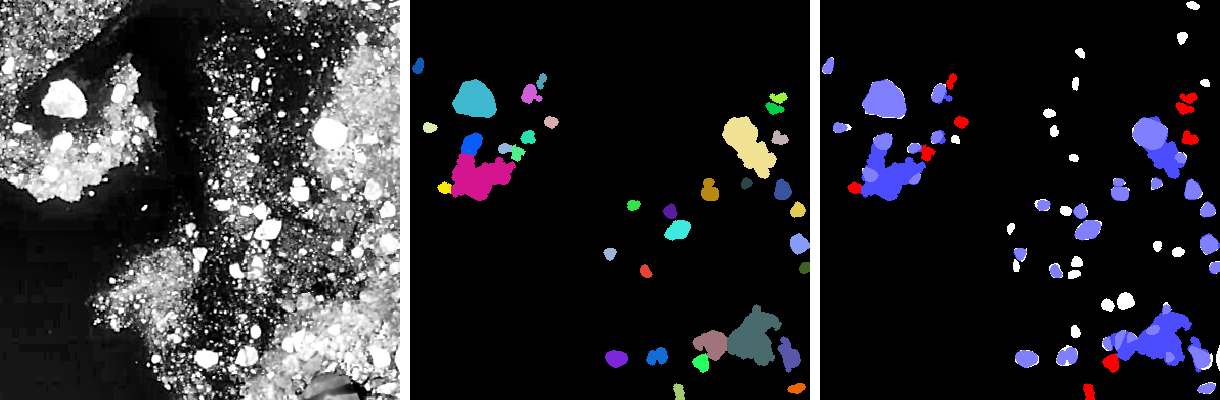

In [337]:
idx = 11
test_img = FSPipeline.assign_labels(kmeans_labels[idx], subset(df_pred_k[idx], :candidate)[:, :label]);

# Test function
overlay = RGBA.(binary_floes[idx])
labeled = kmeans_labels[idx] .> 0
overlay[labeled] .= RGBA.(1, 0, 0)
overlay[test_img .> 0] .= RGBA.(0.3, 0.3, 1)
overlay[test_img .> 0 .&& binary_floes[idx] .> 0] .= RGBA.(0.5, 0.5, 1)

mosaicview(
    preproc_gray[idx], 
    RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], kmeans_labels[idx]))),
    overlay,
npad=10, fillvalue=RGBA(0, 0, 0, 0), nrow=1)

# Visualize candidate selection for k-means result

In [338]:
# Adaptive workflow
@time begin
labeled_floes = label_components.(binary_floes)
df_true = extended_regionprops.(labeled_floes, coastal_buffers, cloud_masks, fc_imgs)
df_pred_a = extended_regionprops.(adapt_labels, coastal_buffers, cloud_masks, fc_imgs);

# Then add the relevant column
for (dft, dfp, lt, lp) in zip(df_true, df_pred_a, labeled_floes, adapt_labels)
    
    relevant_set = FSPipeline.get_relevant_set(dft, dfp, lt, lp)
    
    matched_labels = Int64[]
    for ll in values(relevant_set)
        for L in ll
            push!(matched_labels, L)
        end
    end
    
    matched_labels = unique(matched_labels);
    
    transform!(dfp, :label => ByRow(r -> r ∈ matched_labels) => :candidate)
    
end

df_pred_a_all = vcat(df_pred_a..., cols=:union);
df_pred_a_all[:, :solidity] = df_pred_a_all[:, :area] ./ df_pred_a_all[:, :convex_area];
save("../data/training_floe_properties_adapt.csv", df_pred_a_all)
end
nothing

 62.030347 seconds (1.13 G allocations: 36.442 GiB, 5.65% gc time, 0.05% compilation time)


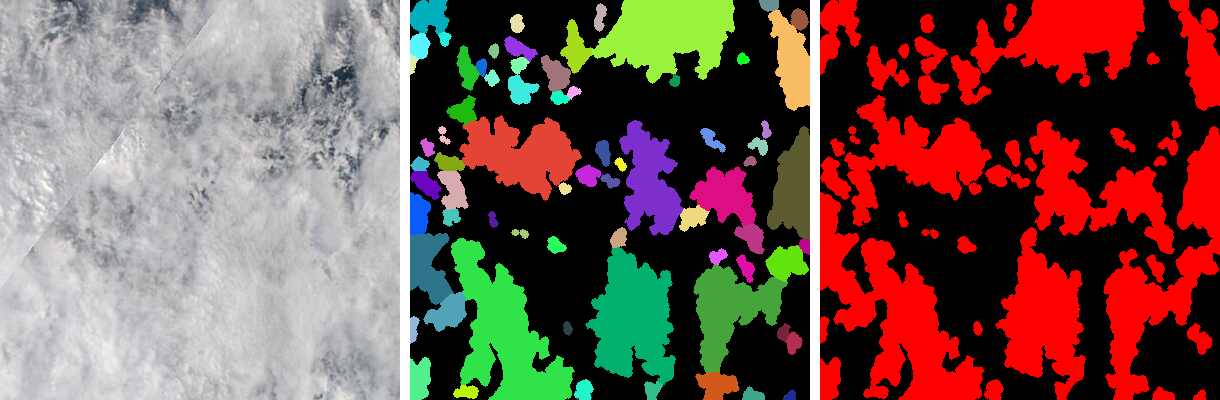

In [339]:
idx = 20
test_img = FSPipeline.assign_labels(adapt_labels[idx], subset(df_pred_a[idx], :candidate)[:, :label]);

# Test function
overlay = RGBA.(binary_floes[idx])
labeled = adapt_labels[idx] .> 0
overlay[labeled] .= RGBA.(1, 0, 0)
overlay[test_img .> 0] .= RGBA.(0.3, 0.3, 1)
overlay[test_img .> 0 .&& binary_floes[idx] .> 0] .= RGBA.(0.5, 0.5, 1)

mosaicview(
    tc_imgs[idx], 
    RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], adapt_labels[idx]))),
    overlay,
npad=10, fillvalue=RGBA(0, 0, 0, 0), nrow=1)

In [340]:
### Fit model for k-means dataset
using GLM
using StatsBase
using Random

# Make "cloudy" column rather than using Float values
df_pred_k_all[:, :cloudy] = df_pred_k_all[:, :cloud_fraction] .> 0.5
df_pred_k_all[:, :length_scale] = df_pred_k_all[:, :area] .^ 0.5

# Select subset such that the classes are balanced between candidates and non-candidates

rng = Random.default_rng(300)
n = minimum(combine(groupby(df_pred_k_all, :candidate), nrow)[:, :nrow])
println("Drawing ", n, " samples of each class")

data_k = []
gdf = groupby(df_pred_k_all, :candidate)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n; replace=false, ordered=true)
    push!(data_k, group[subset_idx, :])
end

train_df_k = vcat(data_k...);

Drawing 750 samples of each class


In [341]:
### Adaptive

# Make "cloudy" column rather than using Float values
df_pred_a_all[:, :cloudy] = df_pred_a_all[:, :cloud_fraction] .> 0.5
df_pred_a_all[:, :length_scale] = df_pred_a_all[:, :area] .^ 0.5

# Select subset such that the classes are balanced between candidates and non-candidates

rng = Random.default_rng(300)
n = minimum(combine(groupby(df_pred_a_all, :candidate), nrow)[:, :nrow])
println("Drawing ", n, " samples of each class")

data_a = []
gdf = groupby(df_pred_a_all, :candidate)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n; replace=false, ordered=true)
    push!(data_a, group[subset_idx, :])
end

train_df_a = vcat(data_a...);

Drawing 893 samples of each class


In [342]:
# Merged results
train_df_ak = vcat(vcat(data_a...), vcat(data_k...));

In [343]:
# Make "cloudy" column rather than using Float values
df_true_all = vcat(df_true..., cols=:union);
df_true_all[:, :solidity] = df_true_all[:, :area] ./ df_true_all[:, :convex_area];
df_true_all[:, :cloudy] = df_true_all[:, :cloud_fraction] .> 0.5
df_true_all[:, :length_scale] = df_true_all[:, :area] .^ 0.5;

In [344]:
# Select subset such that the classes are balanced between candidates and non-candidates

rng = Random.default_rng(300)
n = minimum(combine(groupby(df_true_all, :cloudy), nrow)[:, :nrow])
println("Drawing ", n, " samples of each class")

data = []
gdf = groupby(df_true_all, :cloudy)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n; replace=false, ordered=true)
    push!(data, group[subset_idx, :])
end
train_df = vcat(data...) # true samples
train_df[:, :candidate] .= true

n_false = round(Int64, n/2)

# Subset of non-candidate floes, divide equally into cloudy and noncloudy
### false_positives_k
data_k = []
gdf = groupby(subset(df_pred_k_all, :candidate => r -> .!r), :cloudy)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n_false; replace=false, ordered=true)
    push!(data_k, group[subset_idx, :])
end

### false_postives_a
data_a = []
gdf = groupby(subset(df_pred_a_all, :candidate => r -> .!r), :cloudy)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n_false; replace=false, ordered=true)
    push!(data_a, group[subset_idx, :])
end

train_df = vcat(train_df, vcat(data_k...), vcat(data_a...));

Drawing 365 samples of each class


# Choosing the simplest model
Each combination of variables is possible. We want to have a lower BIC, generally, which weighs the complexity against the skill.

Starting with all the variables, we see find b1 is significant and b2 is not. Without b1, b2 is significant. This is due to b1 and b2 having high correlation.


| $\ell$ | $\mathcal{C}$ | $\overline{B_1}$ | $\overline{B_2}$ | $\overline{B_7}$ | $\overline{\xi_b}$ | cloudy | BIC | r2 |
| -- | -- | -- | -- | -- | -- | -- |   --  | -- |
| 1  | 1  | 1  | 1  | 1  | 1  | 1  |  1167 | 0.47 |
| 0  | 1  | 1  | 1  | 1  | 1  | 1  |  1242 | 0.43 |
| 1  | 0  | 1  | 1  | 1  | 1  | 1  |  1762 | 0.21 |
| 1  | 1  | 0  | 1  | 1  | 1  | 1  |  1184 | 0.46 |
| 1  | 1  | 1  | 0  | 1  | 1  | 1  |  1168 | 0.46 |
| 1  | 1  | 1  | 1  | 0  | 1  | 1  |  1209 | 0.45 |
| 1  | 1  | 1  | 1  | 1  | 0  | 1  |  1197 | 0.45 |
| 1  | 1  | 1  | 1  | 1  | 1  | 0  |  1232 | 0.44 |


Other notes: Running all the model fits one variable at a time, only the circularity shows any skill, with r2 of 0.3.

\* = not significant

| $\ell$ | $\mathcal{C}$ | $\overline{B_1}$ | $\overline{B_2}$ | $\overline{B_7}$ | $\overline{\xi_b}$ | cloudy |  BIC |  r2  |
| --     | --            | --               | --               | --               | --                 | --     |  --  |  --  |
| 1      | 1             | 1               | 1*                | 1                | 1                  | 1      | 1167 | 0.47 |
| 0      | 1             | 1               | 1                 | 1                | 1                  | 1      | 1242 | 0.43 |
| 1      | 0             | 1               | 1                 | 1                | 1                  | 1      | 1762 | 0.21 |
| 1      | 1             | 0               | 1                 | 1                | 1                  | 1      | 1184 | 0.46 |
| 1      | 1             | 1               | 0                 | 1                | 1                  | 1      | 1168 | 0.46 |
| 1      | 1             | 1               | 1                 | 0                | 1                  | 1      | 1209 | 0.45 |
| 1      | 1             | 1               | 1*                | 1                | 0                  | 1      | 1197 | 0.45 |
| 1      | 1             | 1               | 1*                 | 1                | 1                  | 0      | 1232 | 0.44 |

In [423]:
# Only one variable test
for fm in [
    @formula(candidate ~ length_scale),
    @formula(candidate ~ circularity),
    @formula(candidate ~ b1_reflectance_mean),
    @formula(candidate ~ b2_reflectance_mean),
    @formula(candidate ~ b2_bdry_contrast),
    @formula(candidate ~ cloudy),
    ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end

BIC: 2032.5 Pseudo-r2: 0.0
BIC: 1465.8 Pseudo-r2: 0.32
BIC: 1885.4 Pseudo-r2: 0.1
BIC: 1933.1 Pseudo-r2: 0.07
BIC: 1988.0 Pseudo-r2: 0.03
BIC: 2035.8 Pseudo-r2: 0.0


In [427]:
# Leave-one-out test
for fm in [
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~                circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale +               b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity +                       b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean +                     + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean +                       b2_bdry_contrast + cloudy),        
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean +                    cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast         )
        ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end
logit_true

BIC: 1166.9 Pseudo-r2: 0.47
BIC: 1242.2 Pseudo-r2: 0.43
BIC: 1726.2 Pseudo-r2: 0.21
BIC: 1184.6 Pseudo-r2: 0.46
BIC: 1168.4 Pseudo-r2: 0.46
BIC: 1209.4 Pseudo-r2: 0.45
BIC: 1197.0 Pseudo-r2: 0.45
BIC: 1214.9 Pseudo-r2: 0.44


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                           Coef.  Std. Error       z  Pr(>|z|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -20.0811     1.24832     -16.09    <1e-57  -22.5277     -17.6344
length_scale           0.0578536  0.00671713    8.61    <1e-17    0.0446883    0.071019
circularity           13.2862     0.740473     17.94    <1e-71   11.8349      14.7375
b1_reflectance_mean   17.8348     4.34619       4.10    <1e-04    9.31642     26.3532
b2_reflec

In [428]:
# Removing variable "B1"
for fm in [
    @formula(candidate ~ length_scale + circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~                circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale +             + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity +                     + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b2_reflectance_mean +                       b2_bdry_contrast + cloudy),        
    @formula(candidate ~ length_scale + circularity + b2_reflectance_mean + b7_reflectance_mean +                    cloudy),
    @formula(candidate ~ length_scale + circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast         )
        ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end
logit_true

BIC: 1184.6 Pseudo-r2: 0.46
BIC: 1278.8 Pseudo-r2: 0.42
BIC: 1805.6 Pseudo-r2: 0.16
BIC: 1280.2 Pseudo-r2: 0.42
BIC: 1252.0 Pseudo-r2: 0.43
BIC: 1208.6 Pseudo-r2: 0.44
BIC: 1225.1 Pseudo-r2: 0.44


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                           Coef.  Std. Error       z  Pr(>|z|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -17.1329     0.950028    -18.03    <1e-71  -18.9949     -15.2709
length_scale           0.0616746  0.00663784    9.29    <1e-19    0.0486646    0.0746845
circularity           13.6697     0.740245     18.47    <1e-75   12.2188      15.1205
b2_reflectance_mean    6.96561    0.754821      9.23    <1e-19    5.48619      8.44503
b7_reflectance_mean   -1.7849

In [429]:
# Removing variable "B1" and "Length Scale" -- larger drop in performance
for fm in [
    @formula(candidate ~ circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~               b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ circularity +                     + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ circularity + b2_reflectance_mean +                       b2_bdry_contrast + cloudy),        
    @formula(candidate ~ circularity + b2_reflectance_mean + b7_reflectance_mean +                    cloudy),
    @formula(candidate ~ circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast         )
        ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end
logit_true

BIC: 1278.8 Pseudo-r2: 0.42
BIC: 1806.2 Pseudo-r2: 0.16
BIC: 1398.9 Pseudo-r2: 0.36
BIC: 1337.6 Pseudo-r2: 0.39
BIC: 1318.1 Pseudo-r2: 0.4
BIC: 1321.6 Pseudo-r2: 0.4


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast

Coefficients:
──────────────────────────────────────────────────────────────────────────────────
                         Coef.  Std. Error       z  Pr(>|z|)  Lower 95%  Upper 95%
──────────────────────────────────────────────────────────────────────────────────
(Intercept)          -14.3521     0.834258  -17.20    <1e-65  -15.9872   -12.717
circularity           10.885      0.630729   17.26    <1e-66    9.64881   12.1212
b2_reflectance_mean    7.38508    0.729283   10.13    <1e-23    5.95571    8.81445
b7_reflectance_mean   -1.3188     0.326552   -4.04    <1e-04   -1.95883   -0.67877
b2_bdry_contrast       3.30739    0.587066    5.63    <1e-07    2.15676    4.4580

In [ ]:
# Removing variable "B1" and "Contrast"
for fm in [
    @formula(candidate ~ length_scale + circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~                circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale +             + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity +                     + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b2_reflectance_mean +                       b2_bdry_contrast + cloudy),        
    @formula(candidate ~ length_scale + circularity + b2_reflectance_mean + b7_reflectance_mean +                    cloudy),
    @formula(candidate ~ length_scale + circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast         )
        ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end
logit_true

In [426]:
# Leave-one-out test
for fm in [
    @formula(candidate ~                              b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale +                                     b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity +                                             b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean +                                          cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean                           ),
        ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end
logit_true

BIC: 1730.8 Pseudo-r2: 0.2
BIC: 1805.6 Pseudo-r2: 0.16
BIC: 1280.2 Pseudo-r2: 0.42
BIC: 1245.1 Pseudo-r2: 0.43
BIC: 1232.3 Pseudo-r2: 0.44


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                           Coef.  Std. Error       z  Pr(>|z|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -19.0297     1.20269     -15.82    <1e-55  -21.3869     -16.6725
length_scale           0.0600794  0.00661628    9.08    <1e-18    0.0471118    0.0730471
circularity           13.4005     0.734375     18.25    <1e-73   11.9611      14.8398
b1_reflectance_mean   15.6408     4.24975       3.68    0.0002    7.31149     23.9702
b2_reflectance_mean   -6.29

BIC: 2032.5 Pseudo-r2: 0.0
BIC: 1465.8 Pseudo-r2: 0.32
BIC: 1885.4 Pseudo-r2: 0.1
BIC: 1933.1 Pseudo-r2: 0.07
BIC: 1988.0 Pseudo-r2: 0.03
BIC: 2035.8 Pseudo-r2: 0.0


In [401]:
for fm in [
    @formula(candidate ~ length_scale),
    @formula(candidate ~ length_scale + circularity),
    @formula(candidate ~ b1_reflectance_mean + length_scale),
    @formula(candidate ~ b2_reflectance_mean + length_scale),
    @formula(candidate ~ b2_bdry_contrast + length_scale),
    @formula(candidate ~ cloudy + length_scale),
    ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end

BIC: 2032.5 Pseudo-r2: 0.0
BIC: 1339.9 Pseudo-r2: 0.38
BIC: 1882.9 Pseudo-r2: 0.1
BIC: 1931.8 Pseudo-r2: 0.07
BIC: 1991.0 Pseudo-r2: 0.04
BIC: 2039.7 Pseudo-r2: 0.0


In [402]:
for fm in [
    @formula(candidate ~ length_scale),
    @formula(candidate ~ length_scale + circularity),
    @formula(candidate ~ b1_reflectance_mean + circularity),
    @formula(candidate ~ b2_reflectance_mean + circularity),
    @formula(candidate ~ b2_bdry_contrast + circularity),
    @formula(candidate ~ cloudy + circularity),
    ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end

BIC: 2032.5 Pseudo-r2: 0.0
BIC: 1339.9 Pseudo-r2: 0.38
BIC: 1347.2 Pseudo-r2: 0.38
BIC: 1377.4 Pseudo-r2: 0.37
BIC: 1433.3 Pseudo-r2: 0.34
BIC: 1471.1 Pseudo-r2: 0.32


In [416]:
for fm in [
    @formula(candidate ~ b1_reflectance_mean + circularity),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + b2_bdry_contrast),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + cloudy),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + b7_reflectance_mean + b2_bdry_contrast),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + b2_reflectance_mean + circularity + b7_reflectance_mean + b2_bdry_contrast + cloudy)
    ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end

BIC: 1347.2 Pseudo-r2: 0.38
BIC: 1254.5 Pseudo-r2: 0.42
BIC: 1222.2 Pseudo-r2: 0.44
BIC: 1259.8 Pseudo-r2: 0.42
BIC: 1229.0 Pseudo-r2: 0.44
BIC: 1212.3 Pseudo-r2: 0.44
BIC: 1168.4 Pseudo-r2: 0.46
BIC: 1184.6 Pseudo-r2: 0.46


In [ ]:
for fm in [
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + b2_reflectance_mean),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + b2_reflectance_mean + ),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + b2_reflectance_mean),
    ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end

In [ ]:
for fm in [
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + b2_reflectance_mean),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + b2_bdry_contrast),
    @formula(candidate ~ length_scale + b1_reflectance_mean + circularity + cloudy),
    ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end

In [405]:
for fm in [
    @formula(candidate ~ circularity + b7_reflectance_mean),
    @formula(candidate ~ circularity + cloudy),
    @formula(candidate ~ cloudy + b7_reflectance_mean),
    ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end

BIC: 1468.1 Pseudo-r2: 0.33
BIC: 1471.1 Pseudo-r2: 0.32
BIC: 1992.1 Pseudo-r2: 0.03


In [406]:
for fm in [
    @formula(candidate ~ circularity + b2_reflectance_mean),
    @formula(candidate ~ circularity + cloudy),
    @formula(candidate ~ cloudy + b2_reflectance_mean),
    ]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end

BIC: 1377.4 Pseudo-r2: 0.37
BIC: 1471.1 Pseudo-r2: 0.32
BIC: 1931.1 Pseudo-r2: 0.07


In [398]:
for fm in [
    @formula(candidate ~ length_scale + circularity +  b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b7_reflectance_mean + cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b7_reflectance_mean)]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end
# logit_true

BIC: 1184.6 Pseudo-r2: 0.46
BIC: 1805.6 Pseudo-r2: 0.16
BIC: 1280.2 Pseudo-r2: 0.42
BIC: 1229.0 Pseudo-r2: 0.44
BIC: 1195.4 Pseudo-r2: 0.45
BIC: 1228.2 Pseudo-r2: 0.43


In [ ]:
for fm in [
    @formula(candidate ~ length_scale + circularity +  b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b7_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b2_bdry_contrast + cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b7_reflectance_mean + cloudy),
    @formula(candidate ~ length_scale + circularity + b1_reflectance_mean + b7_reflectance_mean)]
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
end

In [395]:
cor(train_df.b1_reflectance_mean, train_df.b2_reflectance_mean)

0.9751249356646466

In [373]:
fm = @formula(candidate ~ length_scale + circularity +  b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy)
logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
logit_true

BIC: 1184.6 Pseudo-r2: 0.46


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast + cloudy

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                           Coef.  Std. Error       z  Pr(>|z|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -17.6337     0.975931    -18.07    <1e-72  -19.5465     -15.721
length_scale           0.0622094  0.00667946    9.31    <1e-19    0.0491179    0.0753009
circularity           13.9119     0.758191     18.35    <1e-74   12.4259      15.3979
b2_reflectance_mean    7.08478    0.768106      9.22    <1e-19    5.57932      8.59024
b7_reflectance_mean  

(1294.515104970356, 0.41045293536211114)

In [346]:
logit_k = glm(fm, Float64.(train_df_k), Binomial(), LogitLink())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                           Coef.  Std. Error       z  Pr(>|z|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -21.0742     1.45351     -14.50    <1e-46  -23.9231     -18.2254
length_scale           0.0461129  0.00751835    6.13    <1e-09    0.0313773    0.0608486
circularity            5.4731     0.622789      8.79    <1e-17    4.25246      6.69374
b1_reflectance_mean   51.4855     5.15413       9.99    <1e-22   41.3836      61.5874
b2_refl

In [347]:
logit_a = glm(fm, Float64.(train_df_a), Binomial(), LogitLink())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                           Coef.  Std. Error       z  Pr(>|z|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -15.1272     1.12974     -13.39    <1e-40  -17.3414     -12.9129
length_scale           0.0315528  0.00406286    7.77    <1e-14    0.0235898    0.0395159
circularity            3.01665    0.525109      5.74    <1e-08    1.98745      4.04584
b1_reflectance_mean   34.2635     4.22191       8.12    <1e-15   25.9887      42.5382
b2_refl

In [348]:
logit_ak = glm(fm, Float64.(train_df_ak), Binomial(), LogitLink())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b1_reflectance_mean + b2_reflectance_mean + b7_reflectance_mean + b2_bdry_contrast

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                           Coef.  Std. Error       z  Pr(>|z|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -17.6176     0.883235    -19.95    <1e-87  -19.3488     -15.8865
length_scale           0.0375772  0.00348353   10.79    <1e-26    0.0307496    0.0444048
circularity            4.08004    0.395111     10.33    <1e-24    3.30563      4.85444
b1_reflectance_mean   41.3514     3.2299       12.80    <1e-36   35.0209      47.6819
b2_refl

In [349]:
coef_dict = Dict(n => v for (v,n) in zip(coef(logit_true), coefnames(logit_true)))


Dict{String, Float64} with 7 entries:
  "circularity"         => 13.2862
  "b1_reflectance_mean" => 17.8348
  "(Intercept)"         => -20.0811
  "length_scale"        => 0.0578536
  "b7_reflectance_mean" => -0.902145
  "b2_bdry_contrast"    => 2.98105
  "b2_reflectance_mean" => -7.77854

In [334]:
cor(train_df.b7_reflectance_mean, train_df.b2_reflectance_mean)

0.3098898694252404

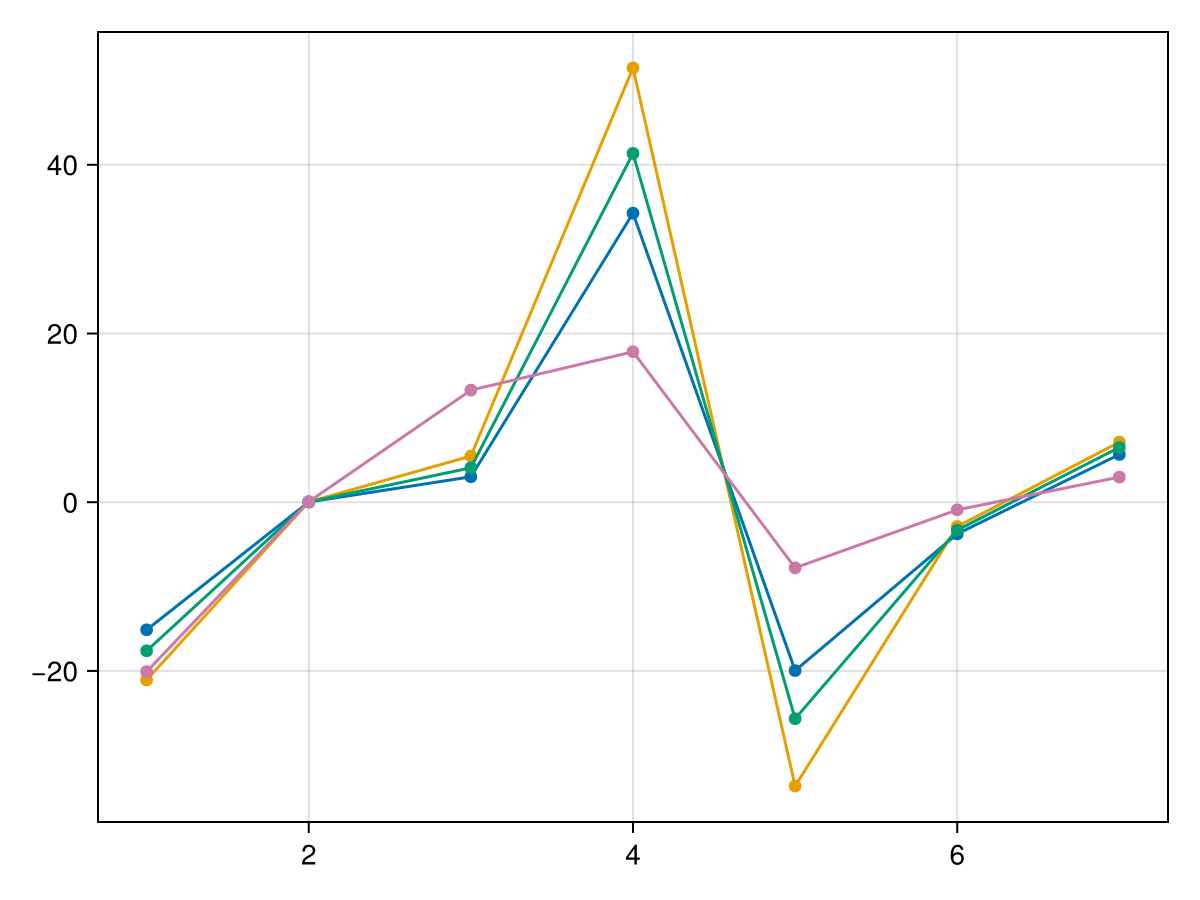

In [350]:
a = scatterlines(coef(logit_a), label="A")
k = scatterlines!(coef(logit_k), label="K")
ak = scatterlines!(coef(logit_ak), label="AK")
t = scatterlines!(coef(logit_true), label="T")
current_figure()

In [331]:
predicted = predict(logit_true) .> 0.5
actual = train_df.candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(train_df), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         598    100
 1         130    630

Recall:    0.86
Precision: 0.83
Accuracy: 0.84
F-score: 0.85


In [252]:
# # These are being added to the FSPipeline / updated
# function keep_labels!(img_indexmap, labels_list)    
#     indices = component_indices(img_indexmap)
#     labels = filter(r -> r > 0, unique(img_indexmap))
#     for L in labels
#         if L ∉ labels_list
#             img_indexmap[indices[L]] .= 0
#         end
#     end
# end
function filter_floes(
    img_indexmap,
    coastal_buffer_mask,
    cloud_mask,
    falsecolor_image;
    min_floe_size=100,
    max_floe_size=90_000,
    expand_radius=15,
    b2_threshold=0.4,
    min_circularity=0.4,
    filter_function=LogisticRegressionFilter, # needs to operate on a dataframe
    min_probability=0.5,
)
    # 1. Remove objects which overlap the coastal mask
    overlap = unique(img_indexmap[coastal_buffer_mask])
    indices = component_indices(img_indexmap)
    for L in overlap
        img_indexmap[indices[L]] .= 0
    end

    # 2. Remove objects outside the specified size bounds prior to extracting features.
    # This is important since the small features can cause problems in some feature
    # descriptors.
    remove_small_segments!(img_indexmap, min_floe_size)
    remove_large_segments!(img_indexmap, max_floe_size)

    # 3. Get object-wise properties
    results_df = regionprops_table(img_indexmap;
        properties=[:label, :area, :convex_area, :perimeter, :bbox, :centroid,
                    :major_axis_length, :minor_axis_length, :orientation]
    )
    # Return blank image if no floes remain
    nrow(results_df) == 0 && return results_df

    results_df[:, :length_scale] = results_df[:, :area] .^ 0.5
    results_df[:, :circularity] = 4 * π * results_df[:, :area] ./ results_df[:, :perimeter] .^ 2
    subset!(results_df, :circularity => r -> r .> min_circularity)
    nrow(results_df) == 0 && return results_df

    labels = results_df[:, :label]
    cloud_fractions = Dict(L => mean(cloud_mask[indices[L]]) for L in labels)
    results_df[:, :cloud_fraction] = [cloud_fractions[L] for L in labels]
    results_df[:, :cloudy] = results_df[:, :cloud_fraction] .> 0.5
    b2 = green.(falsecolor_image)
    b2_means = Dict(L => mean(b2[indices[L]]) for L in labels)
    
    bdry_indexmap = expand_labels(img_indexmap, expand_radius) .- img_indexmap
    bdry_indices = component_indices(bdry_indexmap)
    bdry_labels = intersect(labels, unique(bdry_indexmap))
    b2_bdry_means = Dict(L => mean(b2[bdry_indices[L]]) for L in bdry_labels)
    for L ∈ labels
        if L ∉ bdry_labels
            push!(b2_bdry_means, L => 0)
        end
    end
    results_df[:, :b2_reflectance_mean] = [b2_means[L] for L in labels]
    results_df[:, :b2_reflectance_bdry_mean] = [b2_bdry_means[L] for L in labels]
    results_df[:, :b2_bdry_contrast] = results_df[:, :b2_reflectance_mean] .- results_df[:, :b2_reflectance_bdry_mean]
    subset!(results_df, :b2_reflectance_mean => r -> r .> b2_threshold)
    nrow(results_df) == 0 && return results_df

    results_df[:, :probability] .= filter_function(results_df)
    subset!(results_df, :probability => r -> r .> min_probability)
    return results_df
end

"""
    LogisticRegressionFilter(df; coefs)

Compute the probability for each DataFrameRow using the logistic function
with coefficients defined in `coefs`. Names should include "intercept" and
names of columns in `df`.

"""
function LogisticRegressionFilter(df;
    coefs=Dict(
        "intercept"           => -14.969,
        "circularity"         => 13.1031,
        "length_scale"        => 0.0659,
        "b2_bdry_contrast"    => 3.389,
        "b2_reflectance_mean" => 4.102,
        )
    )
    colnames = [x for x in keys(coefs)]
    b = [x for x in values(coefs)]
    df[:, :intercept] .= 1;
    return 1 ./ (1 .+ exp.(-Matrix(df[:, colnames]) * b))
end

LogisticRegressionFilter

# Checking the performance of the logistic regression filter
Setting the threshold to 0 means that all floes will get returned

18-element Vector{Float64}:
 0.5163095847913373
 0.9339029615267681
 0.6765036116756042
 0.8383755657623215
 0.7610369170393305
 0.7905546264644083
 0.7288840417438379
 0.8640149000466569
 0.7877707249277508
 0.7539754440522066
 0.7542264511335179
 0.9116187859225374
 0.9296649020798562
 0.6628359615043113
 0.8858674804997102
 0.6073111575059602
 0.7747164360980312
 0.7702001355225339

In [259]:
adapt_filtered = filter_floes.(adapt_labels,
    coastal_buffers,
    cloud_masks,
    fc_imgs;
    min_probability=0
);

In [253]:
kmeans_filtered = filter_floes.(kmeans_labels,
    coastal_buffers,
    cloud_masks,
    fc_imgs;
    min_probability=0
);

┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warn

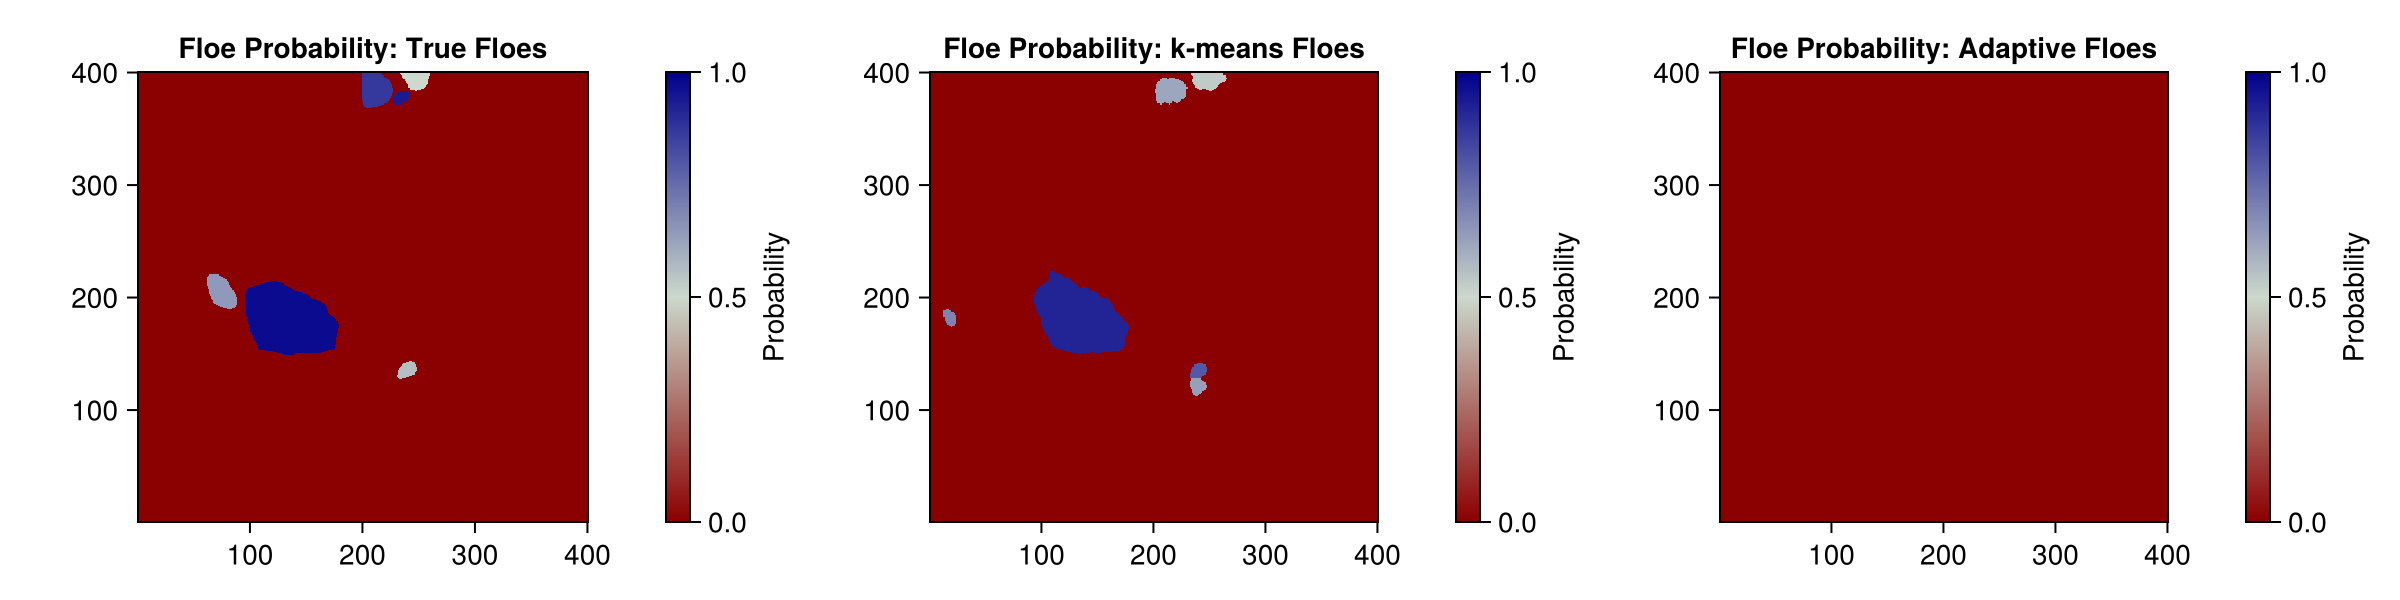

In [260]:
f = Figure(size=(1200, 300))

idx = 1
test_df = filter_floes(labeled_floes[idx],
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx];
    min_probability=0
);

floe_prob_img = zeros(Float64, size(labeled_floes[idx]))
if nrow(test_df) > 0
    indices = component_indices(labeled_floes[idx])
    for (l, p) in zip(test_df.label, test_df.probability)
        l in keys(indices) && (floe_prob_img[indices[l]] .= p)
    end
end
ax = CairoMakie.Axis(f[1,1], title="Floe Probability: True Floes", aspect=1)
c = heatmap!(ax, rotr90(floe_prob_img), colormap=:redsblues, colorrange=(0, 1))
CairoMakie.Colorbar(f[1, 2], c, label="Probability")

test_df = filter_floes(kmeans_labels[idx],
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx]
);

floe_prob_img = zeros(Float64, size(kmeans_labels[idx]))
if nrow(test_df) > 0
    indices = component_indices(kmeans_labels[idx])
    for (l, p) in zip(test_df.label, test_df.probability)
        l in keys(indices) && (floe_prob_img[indices[l]] .= p)
    end
end
ax = CairoMakie.Axis(f[1,3], title="Floe Probability: k-means Floes", aspect=1)
c = heatmap!(ax, rotr90(floe_prob_img), colormap=:redsblues, colorrange=(0, 1))
CairoMakie.Colorbar(f[1, 4], c, label="Probability")


test_df = filter_floes(adapt_labels[idx],
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx]
);

floe_prob_img = zeros(Float64, size(adapt_labels[idx]))
indices = component_indices(adapt_labels[idx])
for (l, p) in zip(test_df.label, test_df.probability)
    l in keys(indices) && (floe_prob_img[indices[l]] .= p)
end

ax = CairoMakie.Axis(f[1,5], title="Floe Probability: Adaptive Floes", aspect=1)
c = heatmap!(ax, rotr90(floe_prob_img), colormap=:redsblues, colorrange=(0, 1))
CairoMakie.Colorbar(f[1, 6], c, label="Probability", colorrange=(0, 1))


current_figure()

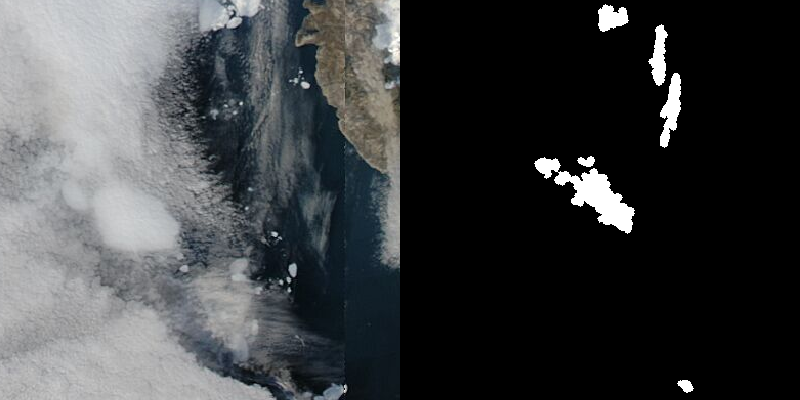

In [258]:
mosaicview(tc_imgs[idx], Gray.(adapt_labels[idx] .> 0), nrow=1)

In [261]:
adapt_filtered[idx].probability

4-element Vector{Float64}:
 0.03964160781101743
 0.12378844422229907
 0.08681369288889185
 0.06907139519481995

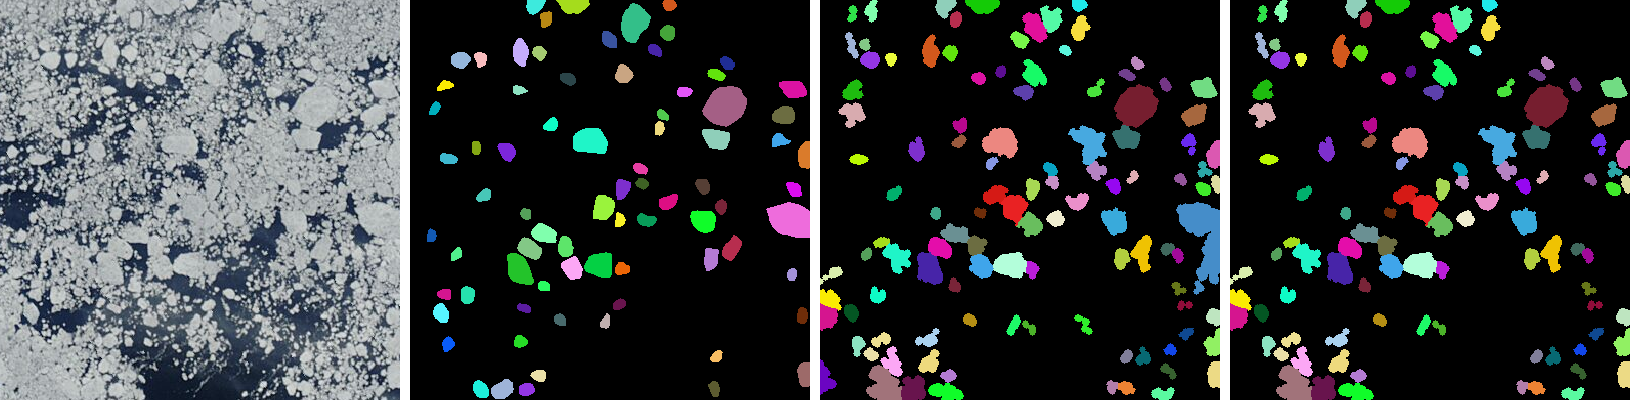

In [314]:
idx = 94

img_indexmap = deepcopy(adapt_labels[idx])

filter_floes!(
    img_indexmap,
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx];
    min_floe_size=100,
    max_floe_size=90_000,
    expand_radius=15,
    filter_function=LogisticRegressionFilter # needs to operate on a dataframe
)

mosaicview(tc_imgs[idx], 
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], labeled_floes[idx]))),
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], adapt_labels[idx]))),
RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], img_indexmap))),
npad=10, fillvalue=RGBA(0, 0, 0, 0),
nrow=1)

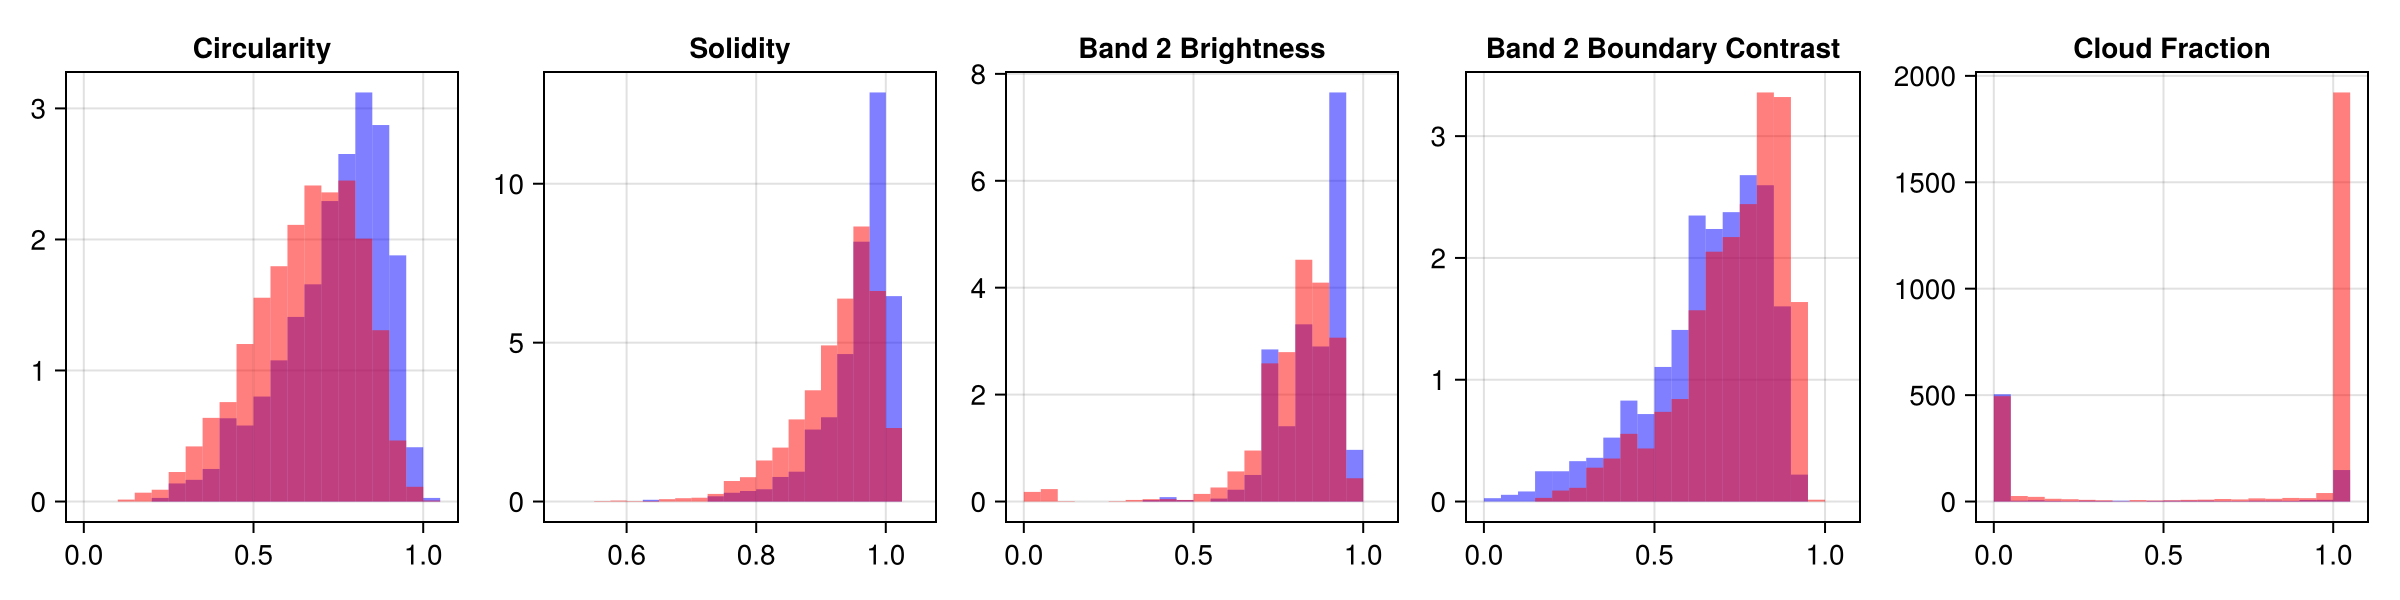

In [104]:
# Example of overlapping distributions
data_candidates = subset(df_pred_k, :candidate)
data_not_candidates = subset(df_pred_k, :candidate => r -> .! r)

f = Figure(size=(1200, 300))
ax = CairoMakie.Axis(f[1, 1], title="Circularity")
hist!(ax, data_candidates[:, :circularity], bins=0:0.05:1.05, color=(:blue, 0.5), normalization = :pdf)
hist!(ax, data_not_candidates[:, :circularity], bins=0:0.05:1.05, color=(:red, 0.5), normalization = :pdf)

ax = CairoMakie.Axis(f[1, 2], title="Solidity")
hist!(ax, data_candidates[:, :solidity], bins=0.5:0.025:1.05, color=(:blue, 0.5), normalization = :pdf)
hist!(ax, data_not_candidates[:, :solidity], bins=0.5:0.025:1.05, color=(:red, 0.5), normalization = :pdf)

ax = CairoMakie.Axis(f[1, 3], title="Band 2 Brightness")
hist!(ax, data_candidates[:, :b2_reflectance_mean], bins=0:0.05:1.05, color=(:blue, 0.5), normalization = :pdf)
hist!(ax, data_not_candidates[:, :b2_reflectance_mean], bins=0:0.05:1.05, color=(:red, 0.5), normalization = :pdf)

hist!(ax, data_candidates[:, :b2_reflectance_bdry_mean], bins=0:0.05:1.05, color=(:blue, 0.5), normalization = :pdf)
ax = CairoMakie.Axis(f[1, 4], title="Band 2 Boundary Contrast")
hist!(ax, data_not_candidates[:, :b2_reflectance_bdry_mean], bins=0:0.05:1.05, color=(:red, 0.5), normalization = :pdf)

ax = CairoMakie.Axis(f[1, 5], title="Cloud Fraction")
hist!(ax, data_candidates[:, :cloud_fraction], bins=0:0.05:1.05, color=(:blue, 0.5))
hist!(ax, data_not_candidates[:, :cloud_fraction], bins=0:0.05:1.05, color=(:red, 0.5))

current_figure()


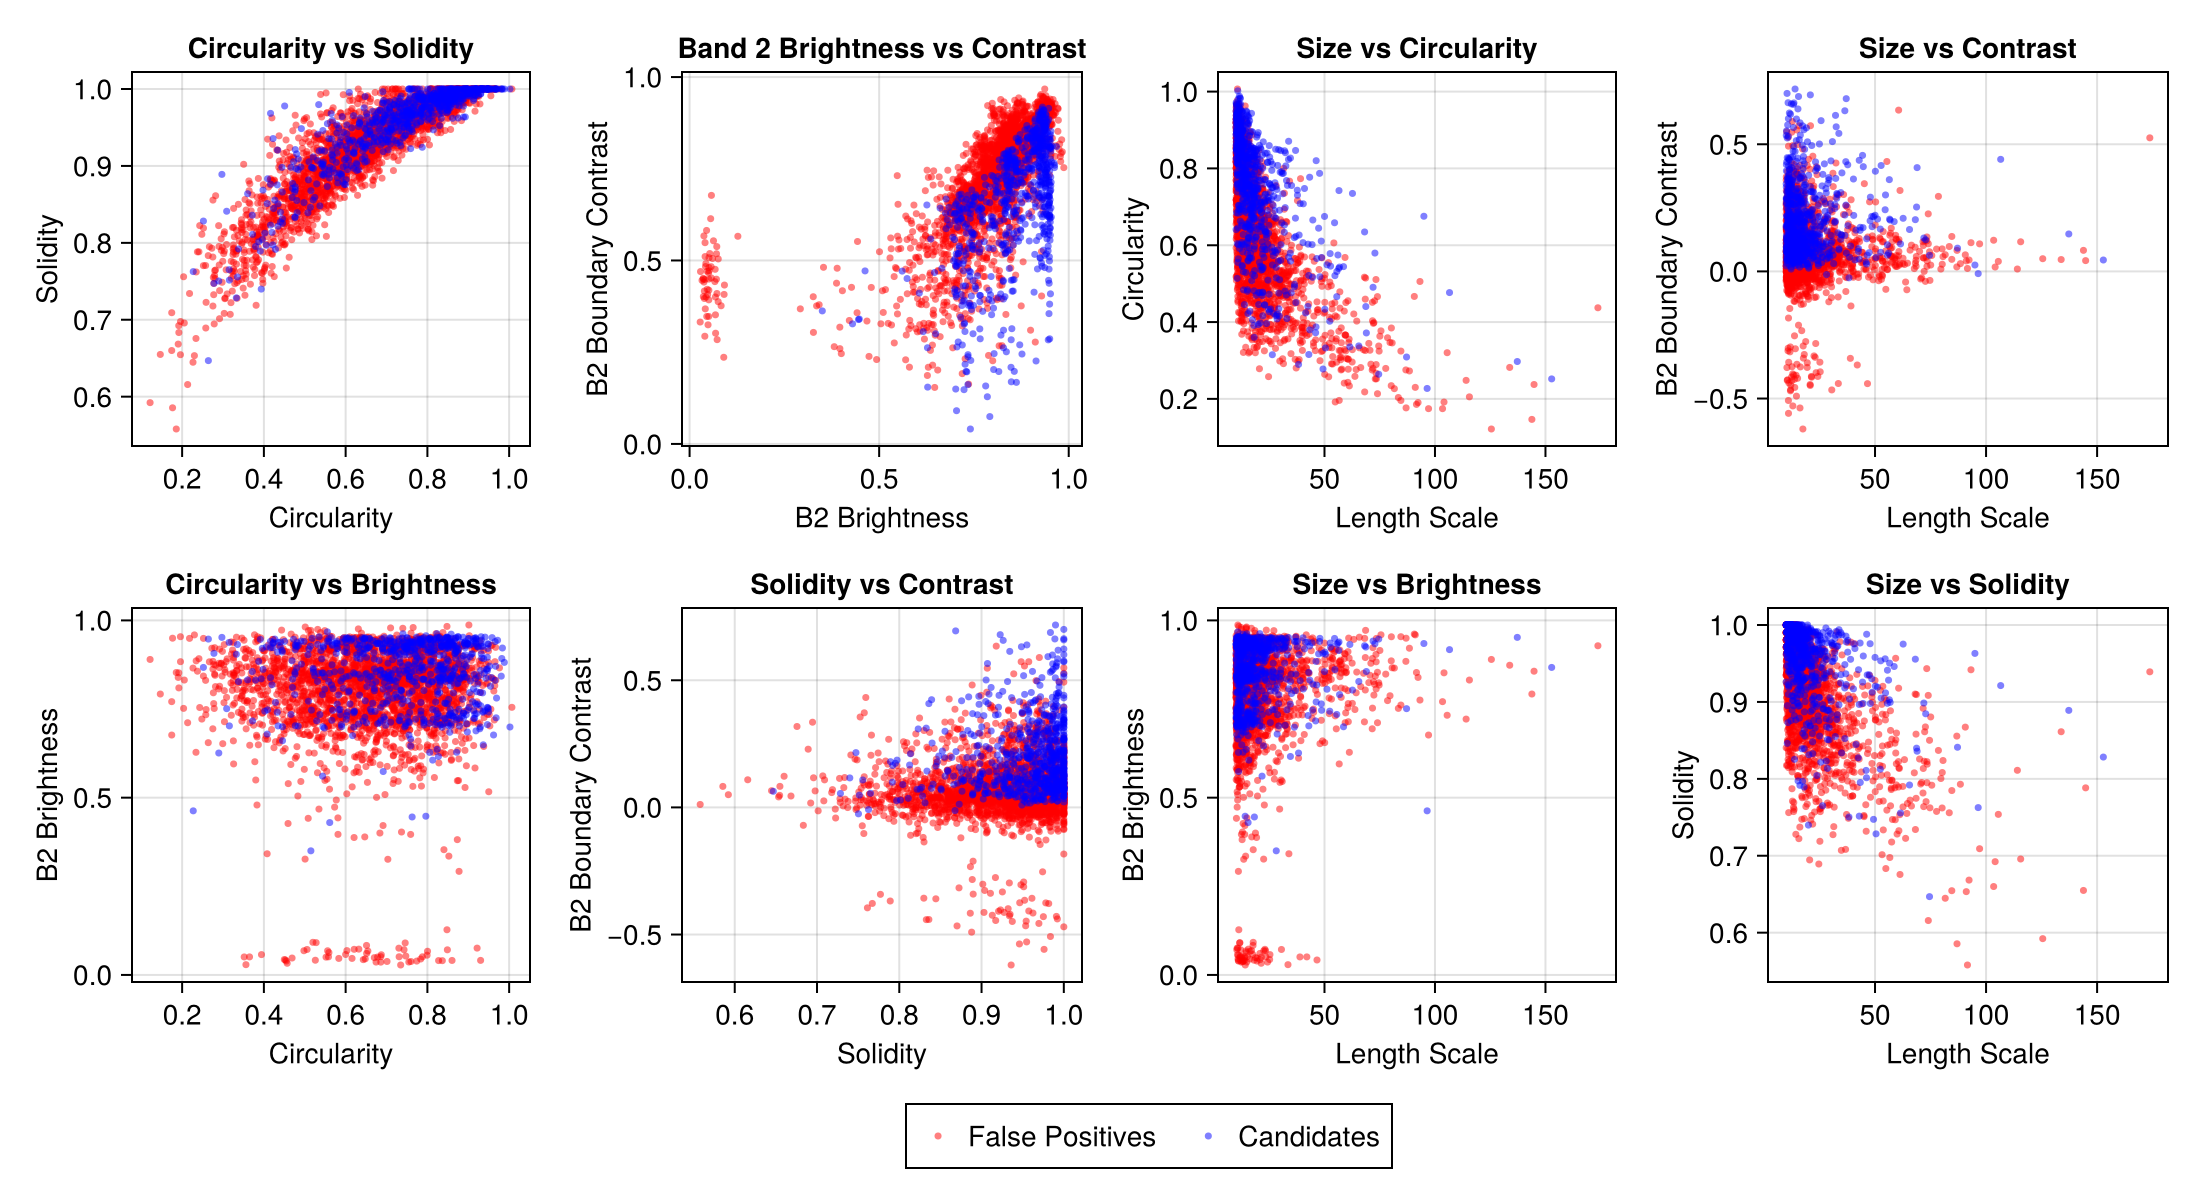

In [332]:
f = Figure(size=(1100, 600))
ax = CairoMakie.Axis(f[1, 1], title="Circularity vs Solidity", xlabel="Circularity", ylabel="Solidity")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :circularity],
             subset(df_pred_all, :candidate => r -> .! r)[:, :solidity],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :circularity],
             subset(df_pred_all, :candidate)[:, :solidity],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[1, 2], title="Band 2 Brightness vs Contrast", xlabel="B2 Brightness", ylabel="B2 Boundary Contrast")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :b2_reflectance_mean],
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_reflectance_bdry_mean],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :b2_reflectance_mean],
             subset(df_pred_all, :candidate)[:, :b2_reflectance_bdry_mean],
    color=(:blue, 0.5), markersize=5)

ax = CairoMakie.Axis(f[1, 3], title="Size vs Circularity", xlabel="Length Scale", ylabel="Circularity")
scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate => r -> .! r)[:, :circularity],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate)[:, :circularity],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[1, 4], title="Size vs Contrast", xlabel="Length Scale", ylabel="B2 Boundary Contrast")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_bdry_contrast],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate)[:, :b2_bdry_contrast],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[2, 1], title="Circularity vs Brightness", xlabel="Circularity", ylabel="B2 Brightness")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :circularity],
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_reflectance_mean],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :circularity],
             subset(df_pred_all, :candidate)[:, :b2_reflectance_mean],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[2, 2], title="Solidity vs Contrast", xlabel="Solidity", ylabel="B2 Boundary Contrast")

scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :solidity],
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_bdry_contrast],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :solidity],
             subset(df_pred_all, :candidate)[:, :b2_bdry_contrast],
    color=(:blue, 0.5), markersize=5)

ax = CairoMakie.Axis(f[2, 3], title="Size vs Brightness", xlabel="Length Scale", ylabel="B2 Brightness")
scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate => r -> .! r)[:, :b2_reflectance_mean],
    color=(:red, 0.5), markersize=5)

scatter!(ax, subset(df_pred_all, :candidate)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate)[:, :b2_reflectance_mean],
    color=(:blue, 0.5), markersize=5)


ax = CairoMakie.Axis(f[2, 4], title="Size vs Solidity", xlabel="Length Scale", ylabel="Solidity")

a1 = scatter!(ax, subset(df_pred_all, :candidate => r -> .! r)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate => r -> .! r)[:, :solidity],
    color=(:red, 0.5), markersize=5)

a2 = scatter!(ax, subset(df_pred_all, :candidate)[:, :area] .^ 0.5,
             subset(df_pred_all, :candidate)[:, :solidity],
    color=(:blue, 0.5), markersize=5)

Legend(f[3, 2:3], [a1, a2], ["False Positives", "Candidates"], orientation = :horizontal)

save("../figures/floe_filter_all.png", f)
current_figure()

The joint distributions for circularity/solidity, brightness and contrast, size vs circularity and size vs contrast all show distinct patterns however simple thresholds are not sufficient for distinguishing the two. Before we jump to the logistic regression function, let's take a look at the difference between clear-sky and cloudy cases. For the k-means approach, there are very few cloudy cases, since it requires clear-sky regions to identify the ice floe cluster. The cloud fraction is nearly bimodal, so we split at 50%.